# Lid Driven Cavity Problem
### Solved using Ansys PyFluent

In [ ]:
%pip install ansys.fluent.core

## MESHING
#### To perform Meshing entirely in Python we use the numpy library. It can sketch the 2D domain, apply the structured quad mesh, define the named boundaries, and export a Fluent-ready .msh file.

In [1]:
import numpy as np
L = 1.0
N = 129
Nc = N - 1

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)

total_nodes = N * N
total_cells = Nc * Nc

def nid(i, j):
    return i * N + j + 1

def cid(i, j):
    return i * Nc + j + 1

interior_faces = []  # (n1, n2, c0, c1)
wall_faces = []      # (n1, n2, c0)
lid_faces = []       # (n1, n2, c0)

# Fluent 2D convention:
#   Face edge n1→n2: normal = CW rotation of (n2-n1) = points to RIGHT of travel
#   Normal direction: from c0 toward c1 (outward for boundary where c1=0)

# Horizontal faces: at y=y[j], edge between nid(i,j) and nid(i+1,j)
for j in range(N):
    for i in range(Nc):
        cell_below = cid(i, j-1) if j > 0 else 0
        cell_above = cid(i, j)   if j < Nc else 0

        if j == 0:
            # Bottom boundary: only cell_above exists, normal must point outward (DOWN)
            # Face rightward: nid(i,j)→nid(i+1,j), normal DOWN, c0=cell_above 
            wall_faces.append((nid(i, j), nid(i+1, j), cell_above))
        elif j == Nc:
            # Top boundary (lid): only cell_below exists, normal must point outward (UP)
            # Face leftward: nid(i+1,j)→nid(i,j), normal UP, c0=cell_below 
            lid_faces.append((nid(i+1, j), nid(i, j), cell_below))
        else:
            # Interior: use rightward direction → normal DOWN → c0=above, c1=below
            interior_faces.append((nid(i, j), nid(i+1, j), cell_above, cell_below))

# Vertical faces: at x=x[i], edge between nid(i,j) and nid(i,j+1) 
for i in range(N):
    for j in range(Nc):
        cell_left  = cid(i-1, j) if i > 0 else 0
        cell_right = cid(i, j)   if i < Nc else 0

        if i == 0:
            # Left boundary: only cell_right exists, normal must point outward (LEFT)
            # Face downward: nid(i,j+1)→nid(i,j), normal LEFT, c0=cell_right 
            wall_faces.append((nid(i, j+1), nid(i, j), cell_right))
        elif i == Nc:
            # Right boundary: only cell_left exists, normal must point outward (RIGHT)
            # Face upward: nid(i,j)→nid(i,j+1), normal RIGHT, c0=cell_left 
            wall_faces.append((nid(i, j), nid(i, j+1), cell_left))
        else:
            # Interior: upward → normal RIGHT → c0=left, c1=right
            interior_faces.append((nid(i, j), nid(i, j+1), cell_left, cell_right))

total_interior = len(interior_faces)
total_wall = len(wall_faces)
total_lid = len(lid_faces)
total_faces = total_interior + total_wall + total_lid

print(f"Nodes: {total_nodes}")
print(f"Cells: {total_cells}")
print(f"Interior: {total_interior}, Wall: {total_wall}, Lid: {total_lid}")
print(f"Total faces: {total_faces}")

assert total_interior == 2 * Nc * (Nc - 1)
assert total_wall == 3 * Nc
assert total_lid == Nc

# For each cell, compute signed area from its face contributions
# Area = sum over faces of: sign * 0.5 * (x1*y2 - x2*y1) where sign depends on c0/c1
def get_coords(node_id):
    # node_id = i*N + j + 1, so i = (node_id-1)//N, j = (node_id-1)%N
    idx = node_id - 1
    ii = idx // N
    jj = idx % N
    return x[ii], y[jj]

cell_area = np.zeros(total_cells + 1)

for n1, n2, c0, c1 in interior_faces:
    x1, y1 = get_coords(n1)
    x2, y2 = get_coords(n2)
    # Face contribution to area (divergence theorem): 0.5*(x1*y2 - x2*y1)
    # This face, from c0's perspective, the normal points outward → positive contribution
    contrib = 0.5 * (x1 * y2 - x2 * y1)
    cell_area[c0] += contrib
    cell_area[c1] -= contrib  # c1 sees flipped normal

for faces in [wall_faces, lid_faces]:
    for n1, n2, c0 in faces:
        x1, y1 = get_coords(n1)
        x2, y2 = get_coords(n2)
        contrib = 0.5 * (x1 * y2 - x2 * y1)
        cell_area[c0] += contrib

neg_cells = np.sum(cell_area[1:] <= 0)
min_area = np.min(cell_area[1:])
max_area = np.max(cell_area[1:])
print(f"Cell areas: min={min_area:.6e}, max={max_area:.6e}")
print(f"Negative/zero area cells: {neg_cells}")

if neg_cells > 0:
    print("ERROR: Still have non-positive cells!")
else:
    print("✓ All cell areas positive")

# ── Write Fluent .msh ──
with open("cavity_fluent.msh", "w") as f:
    f.write('(0 "Lid-Driven Cavity 2D")\n')
    f.write('(2 2)\n')

    f.write(f'(10 (0 1 {total_nodes:x} 0 2))\n')
    f.write(f'(10 (1 1 {total_nodes:x} 1 2)(\n')
    for i in range(N):
        for j in range(N):
            f.write(f'{x[i]:.15e} {y[j]:.15e}\n')
    f.write('))\n')

    f.write(f'(12 (0 1 {total_cells:x} 0))\n')
    f.write(f'(12 (2 1 {total_cells:x} 1 3))\n')

    f.write(f'(13 (0 1 {total_faces:x} 0))\n')

    fid = 1

    # Zone 5: interior (type 2)
    f.write(f'(13 (5 {fid:x} {fid + total_interior - 1:x} 2 2)(\n')
    for n1, n2, c0, c1 in interior_faces:
        f.write(f'{n1:x} {n2:x} {c0:x} {c1:x}\n')
    f.write('))\n')
    fid += total_interior

    # Zone 6: walls (type 3)
    f.write(f'(13 (6 {fid:x} {fid + total_wall - 1:x} 3 2)(\n')
    for n1, n2, c0 in wall_faces:
        f.write(f'{n1:x} {n2:x} {c0:x} 0\n')
    f.write('))\n')
    fid += total_wall

    # Zone 7: lid (type 3)
    f.write(f'(13 (7 {fid:x} {fid + total_lid - 1:x} 3 2)(\n')
    for n1, n2, c0 in lid_faces:
        f.write(f'{n1:x} {n2:x} {c0:x} 0\n')
    f.write('))\n')

    f.write('(45 (2 fluid fluid)())\n')
    f.write('(45 (5 interior default-interior)())\n')
    f.write('(45 (6 wall walls)())\n')
    f.write('(45 (7 wall lid)())\n')

print("✓ cavity_fluent.msh written")

Nodes: 16641
Cells: 16384
Interior: 32512, Wall: 384, Lid: 128
Total faces: 33024
Cell areas: min=6.103516e-05, max=6.103516e-05
Negative/zero area cells: 0
✓ All cell areas positive
✓ cavity_fluent.msh written


## SOLVER

In [20]:
from pathlib import Path
import ansys.fluent.core as pyfluent
# CONSTANTS
U = 0.0014607347          # lid velocity [m/s]
RHO = 1.225         # density [kg/m³]
MU = 1.79e-05             # dynamic viscosity [Pa·s]
# Re = RHO * U * L / MU  (L = 1 m)
MESH_FILE = "cavity_fluent.msh"
# 1. PATHS
mesh_path = Path(MESH_FILE).resolve()
if not mesh_path.exists():
    raise FileNotFoundError(
        f"Mesh file not found: {mesh_path}\n"
        "Place cavity_fluent.msh (Fluent-native format) in the working directory."
    )

# 2. LAUNCH FLUENT
print("Launching Ansys Fluent …")
solver = pyfluent.launch_fluent(
    precision="double",
    dimension=2,
    processor_count=1,
    mode="solver",
    ui_mode="no_gui_or_graphics",
)
print(f"Fluent version: {solver.get_fluent_version()}")

# Convenience aliases
setup    = solver.settings.setup
solution = solver.settings.solution
results  = solver.settings.results

# 3. READ MESH
print(f"Reading mesh: {mesh_path.as_posix()}")
solver.settings.file.read_mesh(file_name=mesh_path.as_posix())
solver.tui.mesh.check()

# 4. GENERAL — Steady, pressure-based
setup.general.solver.type = "pressure-based"
setup.general.solver.time = "steady"

# 5. VISCOUS MODEL — Laminar
setup.models.viscous.model = "laminar"

# 6. MATERIAL PROPERTIES
setup.materials.fluid["air"].density.set_state({
    "option": "constant",
    "value": RHO
})
setup.materials.fluid["air"].viscosity.set_state({
    "option": "constant",
    "value": MU
})

# 7. BOUNDARY CONDITIONS 
setup.boundary_conditions.wall["lid"].momentum.set_state({
    "wall_motion":  "Moving Wall",
    "speed":        U,
    "direction":    [1.0, 0.0, 0.0]
})
setup.boundary_conditions.wall["walls"].momentum.set_state({
    "wall_motion": "Stationary Wall"
})

# 8. SOLUTION METHODS
solution.methods.p_v_coupling.flow_scheme = "SIMPLE"

# 9. RESIDUAL MONITORS
eqns = solution.monitor.residual.equations
eqns["continuity"].absolute_criteria = 1e-6
eqns["x-velocity"].absolute_criteria = 1e-6
eqns["y-velocity"].absolute_criteria = 1e-6

# 10. INITIALIZE
print("Standard initialization …")
solution.initialization.initialization_type = "standard"
solution.initialization.standard_initialize()

# 11. RUN 
# Transient
#  dt = CFL × dx / U
# dx = 1/128 ≈ 0.0078 m  (your 128×128 mesh)
# CFL = 0.5 (safe value)
# dt = 0.5 × 0.0078 / 0.0014607347 ≈ 2.67 s
'''print("Running transient calculation …")
solution.run_calculation.transient_controls.time_step_size = 2.0   # seconds (safe)
solution.run_calculation.dual_time_iterate(
    time_step_count=3500,    # 3500 × 2.0 = 7000 s ≈ 10 flow-through times
    max_iter_per_step=20,
)'''
# Steady
print("Running steady calculation ...")
solution.run_calculation.iterate(iter_count=2000)

# 12. POST-PROCESSING
import numpy as np
from pathlib import Path
from ansys.fluent.core import SurfaceDataType, SurfaceFieldDataRequest, ScalarFieldDataRequest

for name, p0, p1 in [
    ("vertical_line",   [0.5, 0.0, 0.0], [0.5, 1.0, 0.0]),
    ("horizontal_line", [0.0, 0.5, 0.0], [1.0, 0.5, 0.0]),
]:
    if name not in results.surfaces.line_surface:
        results.surfaces.line_surface.create(name=name)
    results.surfaces.line_surface[name].p0 = p0
    results.surfaces.line_surface[name].p1 = p1

fd = solver.fields.field_data

def export_profile(surface, field, coord_idx, filename):
    verts = fd.get_field_data(SurfaceFieldDataRequest(
        surfaces=[surface], data_types=[SurfaceDataType.Vertices]
    ))[surface].vertices

    vals = fd.get_field_data(ScalarFieldDataRequest(
        surfaces=[surface], field_name=field
    ))[surface]

    order = np.argsort(verts[:, coord_idx])
    np.savetxt(filename, np.column_stack([verts[order, coord_idx], vals[order]]),
               delimiter="\t", header="Position\tVelocity", comments="")
    print(f"Exported {filename} ({len(vals)} pts)")

export_profile("vertical_line",   "x-velocity", 1, "centerline_u_velocity.csv")
export_profile("horizontal_line", "y-velocity",  0, "centerline_v_velocity.csv")

# 13. SAVE & EXIT
solver.settings.file.write(file_type="case-data", file_name="lid_driven_cavity.cas.h5")
print("Case+data saved.")
solver.exit()
print("Done.")

Launching Ansys Fluent …
Fluent version: Ansys Fluent 2024 R2
Reading mesh: C:/Users/Dhwani/Desktop/CFD/Ansys_PyFluent/Lid-drivenCavity/PyFluent Files/cavity_fluent.msh
Multicore SMT processors detected. Processor affinity set!

Reading "C:/Users/Dhwani/Desktop/CFD/Ansys_PyFluent/Lid-drivenCavity/PyFluent Files/cavity_fluent.msh"...

Buffering for file scan...

   16641 nodes.
   16384 quadrilateral cells, zone  2.
   32512 2D interior faces, zone  5.
     384 2D wall faces, zone  6.
     128 2D wall faces, zone  7.

Building...
     mesh
     materials,
     interface,
     domains,
     zones,
	lid
	walls
	default-interior
	fluid
     parallel,
Done.

 Domain Extents:
   x-coordinate: min (m) = 0.000000e+00, max (m) = 1.000000e+00
   y-coordinate: min (m) = 0.000000e+00, max (m) = 1.000000e+00
 Volume statistics:
   minimum volume (m3): 6.103516e-05
   maximum volume (m3): 6.103516e-05
     total volume (m3): 1.000000e+00
 Face area statistics:
   minimum face area (m2): 7.812500e-03

## Post-Processing

In [24]:
rho = 1.225          # Density
U = 0.0014607347         # Velocity
L = 1.0              # Characteristic Length (e.g., cavity width)
mu = 1.79e-05        # Dynamic Viscosity

#(Density * Velocity * Length) / Viscosity
reynolds_number = (rho * U * L) / mu
print(f"Inputs: rho={rho}, U={U}, L={L}, mu={mu}")
print(f"The calculated Reynolds Number is: {reynolds_number:.2f}")

if reynolds_number < 2300:
    print("Result: This flow is Laminar (smooth and predictable).")
else:
    print("Result: This flow is likely Turbulent or Transitioning.")

Inputs: rho=1.225, U=0.0014607347, L=1.0, mu=1.79e-05
The calculated Reynolds Number is: 99.97
Result: This flow is Laminar (smooth and predictable).


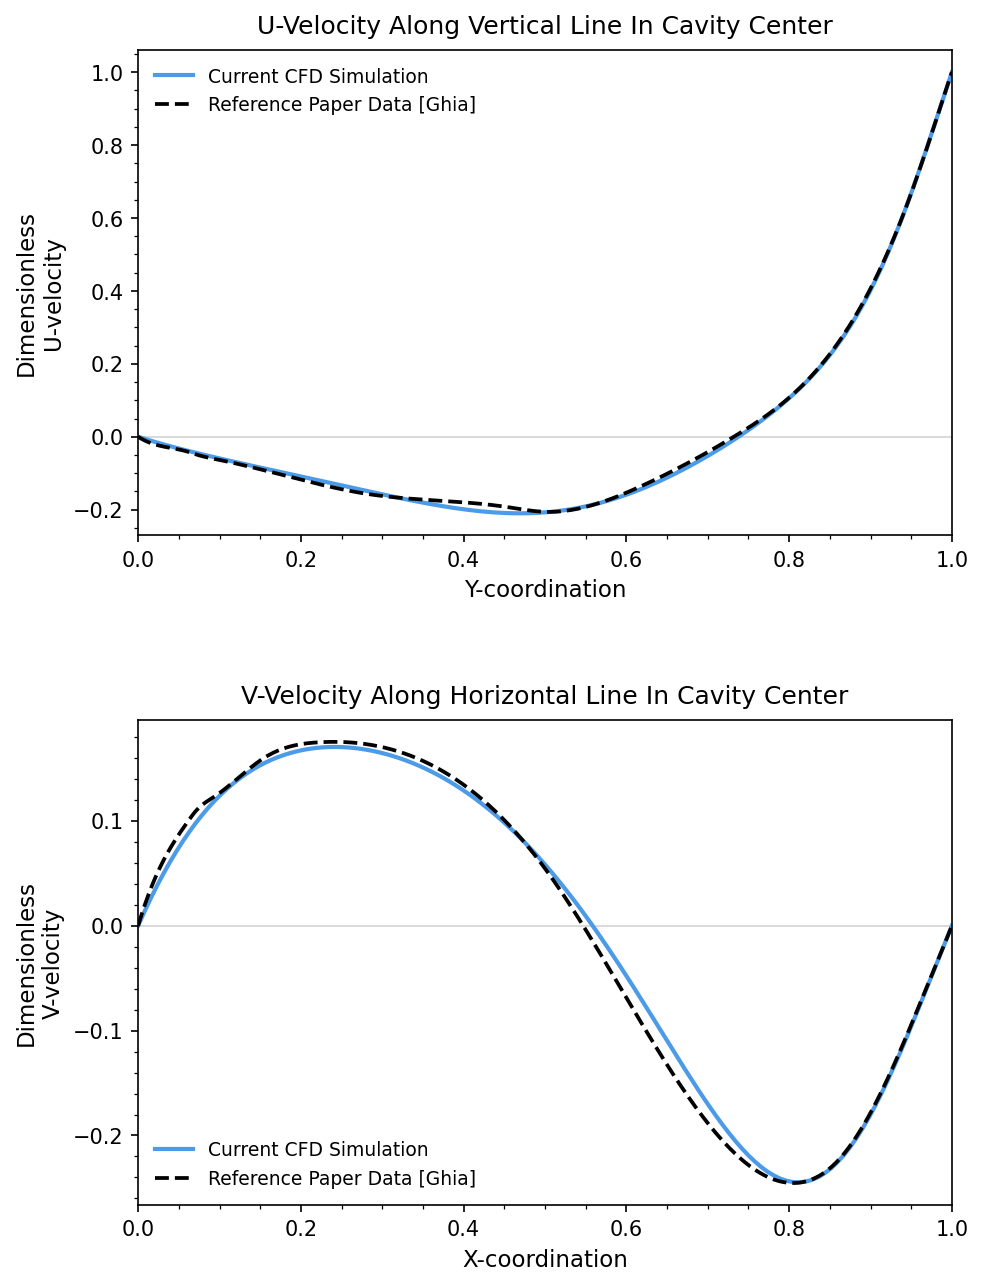

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d

U_LID = 0.001461  # lid velocity [m/s]

def load_csv(filepath):
    data = np.loadtxt(filepath, delimiter='\t', skiprows=1)
    idx = np.argsort(data[:, 0])
    return data[idx, 0], data[idx, 1]

y_sim, u_raw = load_csv('centerline_u_velocity.csv')
x_sim, v_raw = load_csv('centerline_v_velocity.csv')

u_sim = u_raw / U_LID
v_sim = v_raw / U_LID

# GHIA et al. (1982) REFERENCE DATA  Re = 100 
ghia_y = np.array([1.0000, 0.9766, 0.9688, 0.9609, 0.9531,
                   0.8516, 0.7344, 0.6172, 0.5000, 0.4531,
                   0.2813, 0.1719, 0.1016, 0.0703, 0.0625,
                   0.0547, 0.0000])
ghia_u_100 = np.array([ 1.00000,  0.84123,  0.78871,  0.73722,  0.68717,
                         0.23151,  0.00332, -0.13641, -0.20581, -0.19254,
                        -0.15662, -0.10150, -0.06434, -0.04775, -0.04192,
                        -0.03717,  0.00000])

ghia_x = np.array([1.0000, 0.9688, 0.9609, 0.9531, 0.9453,
                   0.9063, 0.8594, 0.8047, 0.5000, 0.2344,
                   0.2266, 0.1563, 0.0938, 0.0703, 0.0625,
                   0.0547, 0.0000])
ghia_v_100 = np.array([ 0.00000, -0.05906, -0.07391, -0.08864, -0.10313,
                        -0.16914, -0.22445, -0.24533,  0.05454,  0.17527,
                         0.17507,  0.16077,  0.12317,  0.10890,  0.10091,
                         0.09233,  0.00000])

# SMOOTH GHIA REFERENCE WITH CUBIC SPLINE 
def smooth(x, y, n=500):
    idx = np.argsort(x)
    xs, ys = x[idx], y[idx]
    f = interp1d(xs, ys, kind='cubic', bounds_error=False,
                 fill_value=(ys[0], ys[-1]))
    xf = np.linspace(xs[0], xs[-1], n)
    return xf, f(xf)

gy_s, gu_s = smooth(ghia_y, ghia_u_100)
gx_s, gv_s = smooth(ghia_x, ghia_v_100)

# PLOT
fig, axes = plt.subplots(2, 1, figsize=(7, 10), dpi=150)
fig.subplots_adjust(hspace=0.38)

CFD = dict(color='#4C9BE8', linewidth=2.0, linestyle='-',  label='Current CFD Simulation')
REF = dict(color='black',   linewidth=1.8, linestyle='--', label='Reference Paper Data [Ghia]')

# — U-velocity: vertical centreline (x = 0.5) —
ax = axes[0]
ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)
ax.plot(y_sim, u_sim, **CFD)
ax.plot(gy_s,  gu_s,  **REF)
ax.set_title('U-Velocity Along Vertical Line In Cavity Center', fontsize=12, pad=8)
ax.set_xlabel('Y-coordination', fontsize=11)
ax.set_ylabel('Dimensionless\nU-velocity', fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(fontsize=9, frameon=False)
ax.grid(False)

# — V-velocity: horizontal centreline (y = 0.5) —
ax = axes[1]
ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)
ax.plot(x_sim, v_sim, **CFD)
ax.plot(gx_s,  gv_s,  **REF)
ax.set_title('V-Velocity Along Horizontal Line In Cavity Center', fontsize=12, pad=8)
ax.set_xlabel('X-coordination', fontsize=11)
ax.set_ylabel('Dimensionless\nV-velocity', fontsize=11)
ax.set_xlim(0, 1)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(fontsize=9, frameon=False, loc='lower left')
ax.grid(False)

plt.savefig('validation_plot.png', dpi=200, bbox_inches='tight')
plt.show()